In [29]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import pickle as pk
from astropy.io import fits
%matplotlib inline



In [30]:
# df = pk.load(open('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/results/mock_gen/maps_websky/RUN2_v0_tau_sim_B16_nside_1024_split_0_1.pkl','rb'))
# map_ymap = df['map_ymap']
# map_tau = df['map_tau']
# map_ksz = df['map_ksz']

# nside = 2048
# map_tau = np.zeros(hp.nside2npix(nside))
# ndevices = 4

# for jd in range(ndevices):
#     df = pk.load(open(f'/mnt/ceph/users/spandey/ltu-godmax/GODMAX/results/mock_gen/maps_websky/RUN2_v3_tau_sim_B16_nside_{nside}_split_{jd}_{ndevices}.pkl','rb'))
#     map_tau += df['map_tau']


nside = 4096
map_tau = np.zeros(hp.nside2npix(nside))
map_ymap = np.zeros(hp.nside2npix(nside))
map_ksz = np.zeros(hp.nside2npix(nside))
ndevices = 8

for jd in range(ndevices):
    df = pk.load(open(f'/mnt/ceph/users/spandey/ltu-godmax/GODMAX/results/mock_gen/maps_websky/RUN2_v3_tau_sim_B16_nside_{nside}_split_{jd}_{ndevices}.pkl','rb'))
    map_tau += df['map_tau']
    map_ymap += df['map_ymap']
    map_ksz += df['map_ksz']



In [31]:
hp.write_map('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/results/mock_gen/maps_websky/RUN2_v3_tau_sim_B16_nside_4096_fullsky.fits', map_tau, overwrite=True)
hp.write_map('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/results/mock_gen/maps_websky/RUN2_v3_ymap_sim_B16_nside_4096_fullsky.fits', map_ymap, overwrite=True)
hp.write_map('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/results/mock_gen/maps_websky/RUN2_v3_ksz_sim_B16_nside_4096_fullsky.fits', map_ksz, overwrite=True)




setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


In [13]:
# df = fits.open('/mnt/ceph/users/spandey/websky/halo_input_wM200c_zmax2p5_minM200m_4e13_new.fits')
# ra_all = df[1].data['ra']
# dec_all = df[1].data['dec']
# z_all = df[1].data['z']
# M200c_all = df[1].data['M200c_wh']
# M200m_all = df[1].data['M200m_wh']
# vlos_all = df[1].data['vrad']




In [ ]:
# print(np.amin(np.log10(M200m_all)), np.amax(np.log10(M200m_all)))


13.602060029395783 15.37211897454516


In [22]:
df = fits.open('/mnt/ceph/users/spandey/websky/halo_input_wM200c_zmax2p5_minM200m_4e13_new.fits')
ra_all = df[1].data['ra']
dec_all = df[1].data['dec']
z_all = df[1].data['z']
M200c_all = df[1].data['M200c_wh']
M200m_all = df[1].data['M200m_wh']
vlos_all = df[1].data['vrad']

# zmin = 0.2
# zmax = 0.5

zmin = 0.5
zmax = 1.0


indsel = np.where((z_all>zmin) & (z_all<zmax) & (M200m_all>6e13) & (M200m_all<5e15))[0]

ra_all = ra_all[indsel]
dec_all = dec_all[indsel]
z_all = z_all[indsel]
M200c_all = M200c_all[indsel]
M200m_all = M200m_all[indsel]
vlos_all = vlos_all[indsel]

print(np.log10(np.amin(M200c_all)), np.log10(np.amax(M200c_all)))

map_halo = np.zeros(12 * nside**2, dtype=np.float32)
pix_halo = hp.ang2pix(nside, ra_all, dec_all, lonlat=True)
np.add.at(map_halo, pix_halo, 1.)
delta_map_halo = map_halo/np.mean(map_halo)





13.707664460079679 15.208053034563665


In [23]:
# Cl_gy = hp.anafast(delta_map_halo, map_ymap)
Cl_gtau = hp.anafast(delta_map_halo, map_tau)
# Cl_gksz = hp.anafast(delta_map_halo, map_ksz)




In [24]:
ell_array = np.arange(len(Cl_gtau))
fac = ell_array*(ell_array+1)/(2*np.pi)



In [25]:
# df_th = np.loadtxt('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/pasting/run_scripts/websky/comp_class_sz.txt')

df_th = np.loadtxt('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/pasting/run_scripts/websky/comp_class_sz2.txt')

ell_th, Cl_th = df_th[:,0], df_th[:,1]


(10.0, 8000.0)

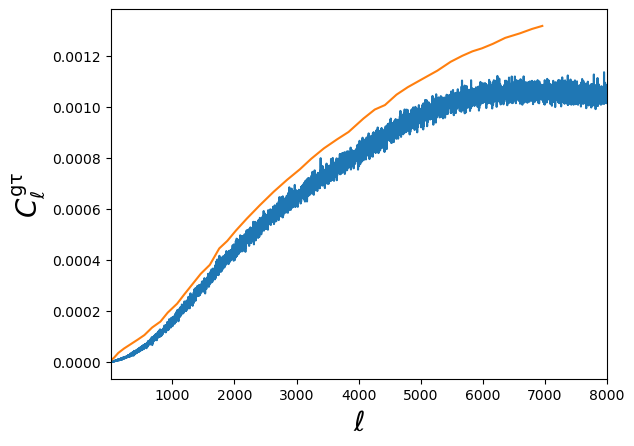

In [26]:
plt.figure()
plt.plot(ell_array,fac*Cl_gtau/(hp.pixwin(nside)))
plt.plot(ell_th, Cl_th, label='theory')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell^{\mathrm{g\tau}}$', fontsize=20)
# plt.ylim(5e-10, 1e-7)
plt.xlim(10, 8000)




(10.0, 8000.0)

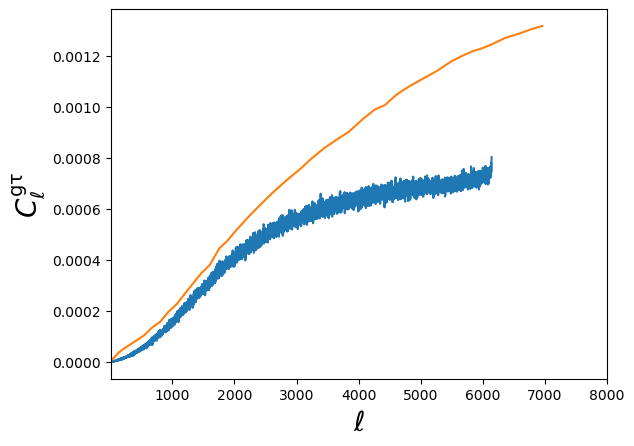

In [20]:
plt.figure()
plt.plot(ell_array,fac*Cl_gtau/(hp.pixwin(nside)))
plt.plot(ell_th, Cl_th, label='theory')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell^{\mathrm{g\tau}}$', fontsize=20)
# plt.ylim(5e-10, 1e-7)
plt.xlim(10, 8000)


